In [38]:
import subprocess
result = subprocess.run(
    ["pip", "install", "ragas", "--break-system-packages"],
    capture_output=True, text=True
)
print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
print(result.stderr[-300:] if result.stderr else "")

2.0 in /usr/local/lib/python3.11/site-packages (from rich>=12.3.0->typer->huggingface-hub<2.0,>=0.25.0->datasets->ragas) (4.0.0)

: https://pip.pypa.io/warnings/venv

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



In [39]:
import chromadb

client = chromadb.PersistentClient(path=str(CHROMA_BASE_DIR))
collections = client.list_collections()

print(f"CHROMA_BASE_DIR: {CHROMA_BASE_DIR}")
print(f"\n存在するコレクション:")
for col in collections:
    print(f"  {col.name}: {col.count()}件")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


CHROMA_BASE_DIR: /app/data/chroma

存在するコレクション:
  diabetes_rag_strategy_c: 0件


In [40]:
import sqlite3
conn = sqlite3.connect("/app/data/chroma/chroma.sqlite3")
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM embeddings")
print(f"SQLite embeddings件数: {cursor.fetchone()[0]}")
conn.close()

SQLite embeddings件数: 0


In [43]:
import os
import re
from pathlib import Path
from dotenv import load_dotenv
from langchain_chroma import Chroma
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.document_loaders import PyMuPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.schema import Document as LCDocument
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from datasets import Dataset
import chromadb

load_dotenv()

CHROMA_BASE_DIR = Path("/app/data/chroma")
PACKAGE_INSERT_DIR = Path("/app/data/raw/package_inserts")
GUIDELINE_DIR = Path("/app/data/raw/guidelines")
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
ragas_llm = LangchainLLMWrapper(llm)
ragas_embeddings = LangchainEmbeddingsWrapper(embeddings)

print("import・環境設定完了")

import・環境設定完了


In [44]:
PACKAGE_INSERT_FILES = [
    "metformin.pdf", "glimepiride.pdf", "empagliflozin.pdf",
    "semaglutide.pdf", "sitagliptin.pdf", "linagliptin.pdf",
    "insulin_glargine.pdf", "insulin_aspart.pdf"
]
GUIDELINE_FILES = ["diabetes_manual_2025.pdf"]

target_sections = [
    "警告", "禁忌", "組成", "性状", "効能", "効果",
    "用法", "用量", "注意", "相互作用", "副作用",
    "過量投与", "薬物動態", "臨床成績", "薬効", "薬理",
    "有効成分", "取扱い", "包装", "承認"
]

section_pattern = re.compile(
    r'(?:^|\n)'
    r'(\d+(?:\.\d+)?)'
    r'[\.\s　 ]*'
    r'([^\n\d]{2,30})',
    re.MULTILINE
)

def load_pdfs_with_metadata(file_list, doc_type, pdf_dir):
    docs = []
    for fname in file_list:
        fpath = pdf_dir / fname
        if not fpath.exists():
            print(f"ファイルが見つかりません: {fname}")
            continue
        loader = PyMuPDFLoader(str(fpath))
        pages = loader.load()
        drug_name = fname.replace(".pdf", "")
        for page in pages:
            page.metadata["file_name"] = fname
            page.metadata["doc_type"] = doc_type
            page.metadata["drug_name"] = drug_name
        docs.extend(pages)
        print(f"  読み込み完了: {fname} ({len(pages)}ページ)")
    return docs

def split_by_section(all_docs, max_section_size=1000,
                     fallback_chunk_size=500, fallback_overlap=50):
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=fallback_chunk_size,
        chunk_overlap=fallback_overlap
    )
    all_chunks = []

    for doc in all_docs:
        if doc.metadata.get("doc_type") == "guideline":
            chunks = text_splitter.split_documents([doc])
            all_chunks.extend(chunks)
            continue

        text = doc.page_content
        matches = [
            m for m in section_pattern.finditer(text)
            if any(target in m.group(2) for target in target_sections)
        ]

        if not matches:
            chunks = text_splitter.split_documents([doc])
            all_chunks.extend(chunks)
            continue

        for i, match in enumerate(matches):
            start = match.start()
            end = matches[i+1].start() if i+1 < len(matches) else len(text)
            section_text = text[start:end].strip()
            section_name = f"{match.group(1)}. {match.group(2).strip()}"

            if len(section_text) > max_section_size:
                sub_doc = LCDocument(
                    page_content=section_text,
                    metadata=doc.metadata.copy()
                )
                sub_chunks = text_splitter.split_documents([sub_doc])
                for sub_chunk in sub_chunks:
                    sub_chunk.metadata["section"] = section_name
                    sub_chunk.metadata["section_number"] = match.group(1)
                all_chunks.extend(sub_chunks)
            else:
                chunk = LCDocument(
                    page_content=section_text,
                    metadata={
                        **doc.metadata,
                        "section": section_name,
                        "section_number": match.group(1)
                    }
                )
                all_chunks.append(chunk)

    return all_chunks

# PDF読み込み
print("PDF読み込み開始...")
insert_docs = load_pdfs_with_metadata(
    PACKAGE_INSERT_FILES, "package_insert", PACKAGE_INSERT_DIR
)
guideline_docs = load_pdfs_with_metadata(
    GUIDELINE_FILES, "guideline", GUIDELINE_DIR
)
all_docs = insert_docs + guideline_docs
print(f"\n合計: {len(all_docs)}ページ")

# セクション分割
print("\nセクション分割中...")
section_chunks = split_by_section(all_docs)
section_chunks = [c for c in section_chunks if c.page_content.strip()]
print(f"分割完了: {len(section_chunks)}チャンク")

# ChromaDB登録
print("\nChromaDB登録中...")
client = chromadb.PersistentClient(path=str(CHROMA_BASE_DIR))
try:
    client.delete_collection("diabetes_rag_strategy_c")
    print("既存コレクション削除完了")
except:
    print("削除対象なし")

vectorstore = Chroma.from_documents(
    documents=section_chunks,
    embedding=embeddings,
    collection_name="diabetes_rag_strategy_c",
    persist_directory=str(CHROMA_BASE_DIR)
)

print(f"\n登録完了: {vectorstore._collection.count()}チャンク")

PDF読み込み開始...
  読み込み完了: metformin.pdf (7ページ)
  読み込み完了: glimepiride.pdf (6ページ)
  読み込み完了: empagliflozin.pdf (9ページ)
  読み込み完了: semaglutide.pdf (6ページ)
  読み込み完了: sitagliptin.pdf (6ページ)
  読み込み完了: linagliptin.pdf (6ページ)
  読み込み完了: insulin_glargine.pdf (6ページ)
  読み込み完了: insulin_aspart.pdf (4ページ)


Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


  読み込み完了: diabetes_manual_2025.pdf (19ページ)

合計: 69ページ

セクション分割中...
分割完了: 477チャンク

ChromaDB登録中...
既存コレクション削除完了

登録完了: 477チャンク


In [45]:
eval_questions = [
    {
        "id": "Q01", "category": "禁忌",
        "question": "メトホルミンの禁忌を教えてください",
        "relevant_docs": ["metformin.pdf"],
        "relevant_keywords": ["乳酸アシドーシス", "腎機能障害", "eGFR", "30", "透析", "造影剤", "禁忌"]
    },
    {
        "id": "Q02", "category": "用法用量",
        "question": "グリメピリドの用法・用量を教えてください",
        "relevant_docs": ["glimepiride.pdf"],
        "relevant_keywords": ["0.5mg", "1日1回", "朝食前", "最高投与量", "6mg", "維持量"]
    },
    {
        "id": "Q03", "category": "副作用",
        "question": "エンパグリフロジンの主な副作用を教えてください",
        "relevant_docs": ["empagliflozin.pdf"],
        "relevant_keywords": ["性器感染症", "尿路感染症", "低血糖", "ケトアシドーシス", "頻尿"]
    },
    {
        "id": "Q04", "category": "禁忌",
        "question": "オゼンピックの禁忌を教えてください",
        "relevant_docs": ["semaglutide.pdf"],
        "relevant_keywords": ["甲状腺髄様癌", "多発性内分泌腫瘍症", "過敏症", "禁忌"]
    },
    {
        "id": "Q05", "category": "薬剤比較",
        "question": "腎機能が低下している患者に使用できる糖尿病薬は何ですか",
        "relevant_docs": ["linagliptin.pdf", "insulin_glargine.pdf"],
        "relevant_keywords": ["リナグリプチン", "腎機能", "用量調節不要", "インスリン", "eGFR"]
    },
    {
        "id": "Q06", "category": "薬剤比較",
        "question": "DPP-4阻害薬のジャヌビアとトラゼンタの腎機能低下時の使い分けを教えてください",
        "relevant_docs": ["sitagliptin.pdf", "linagliptin.pdf"],
        "relevant_keywords": ["シタグリプチン", "リナグリプチン", "用量調節", "腎機能", "eGFR"]
    },
    {
        "id": "Q07", "category": "薬剤比較",
        "question": "インスリン グラルギンとインスリン アスパルトの違いを教えてください",
        "relevant_docs": ["insulin_glargine.pdf", "insulin_aspart.pdf"],
        "relevant_keywords": ["持効型", "超速効型", "基礎インスリン", "食後血糖", "作用時間"]
    },
    {
        "id": "Q08", "category": "ガイドライン",
        "question": "糖尿病の血糖コントロール目標を教えてください",
        "relevant_docs": ["diabetes_manual_2025.pdf"],
        "relevant_keywords": ["HbA1c", "7.0%", "空腹時血糖", "130mg/dl"]
    },
    {
        "id": "Q09", "category": "ガイドライン",
        "question": "2型糖尿病の薬物療法の第一選択薬は何ですか",
        "relevant_docs": ["diabetes_manual_2025.pdf"],
        "relevant_keywords": ["ビグアナイド", "メトホルミン", "ステップ1", "食事療法", "運動療法"]
    },
    {
        "id": "Q10", "category": "横断検索",
        "question": "心血管疾患を合併した2型糖尿病患者に推奨される薬剤は何ですか",
        "relevant_docs": ["empagliflozin.pdf", "semaglutide.pdf", "diabetes_manual_2025.pdf"],
        "relevant_keywords": ["SGLT2阻害薬", "心血管疾患", "心不全", "微量アルブミン尿", "ステップ2"]
    },
]

print(f"評価質問セット: {len(eval_questions)}問")

評価質問セット: 10問


In [52]:
GUIDELINE_KEYWORDS = [
    "ガイドライン", "推奨", "第一選択", "治療方針",
    "血糖コントロール", "目標", "標準治療"
]

question_patterns = {
    "禁忌":      [1, 2, 8, 10, 14, 16],
    "用法用量":   [6, 7, 8, 9],
    "副作用":    [1, 8, 9, 11],
    "腎機能":    [1, 2, 6, 7, 8, 9, 14, 16],
    "妊婦":      [2, 9],
    "相互作用":  [1, 2, 8, 10],
    "薬物動態":  [8, 9, 13],
    "作用機序":  [15, 18], 
    "薬剤比較":  [4, 6, 7, 8, 9, 14, 16, 18], 
}

pattern_descriptions = """
- 禁忌：投与してはいけない患者・条件に関する質問
- 用法用量：投与方法・投与量・投与回数に関する質問
- 副作用：副作用・有害事象に関する質問
- 腎機能：腎機能障害患者への投与・用量調節に関する質問
- 妊婦：妊婦・授乳婦・生殖への影響に関する質問
- 相互作用：他の薬剤との併用・相互作用に関する質問
- 薬物動態：吸収・分布・代謝・排泄に関する質問
- 作用機序：薬効・作用機序に関する質問
- 薬剤比較：複数薬剤の違い・使い分けに関する質問
"""

def detect_sections(question: str, llm) -> tuple:
    prompt = f"""
以下は医薬品に関する質問パターンの一覧です。
{pattern_descriptions}

次の質問が該当するパターンを全て選んでください。
パターン名のみをカンマ区切りで答えてください。
例：禁忌, 腎機能
該当するものがない場合は「該当するパターンはありません。」と答えてください。

質問：{question}

該当するパターン：
"""
    response = llm.invoke(prompt)
    response_text = response.content.strip()

    section_numbers = []
    for pattern_name, numbers in question_patterns.items():
        if pattern_name in response_text:
            for num in numbers:
                if num not in section_numbers:
                    section_numbers.append(num)

    is_guideline_query = any(kw in question for kw in GUIDELINE_KEYWORDS)
    return section_numbers, response_text, is_guideline_query


def detect_drug_names(question: str, llm) -> list:
    drug_map = """
    - メトホルミン、メトグルコ → metformin
    - グリメピリド、アマリール → glimepiride
    - エンパグリフロジン、ジャディアンス → empagliflozin
    - セマグルチド、オゼンピック、リベルサス → semaglutide
    - シタグリプチン、ジャヌビア → sitagliptin
    - リナグリプチン、トラゼンタ → linagliptin
    - インスリン グラルギン、ランタス → insulin_glargine
    - インスリン アスパルト、ノボラピッド → insulin_aspart
    """
    prompt = f"""
以下は薬剤名とファイル名の対応表です。
{drug_map}

次の質問に登場する薬剤のファイル名を全て答えてください。
ファイル名のみをカンマ区切りで答えてください。
特定の薬剤名がない場合は「なし」と答えてください。
例：metformin, glimepiride

質問：{question}

ファイル名：
"""
    response = llm.invoke(prompt)
    response_text = response.content.strip()

    if "なし" in response_text:
        return []

    drug_names = [
        name.strip()
        for name in response_text.replace("、", ",").split(",")
        if name.strip()
    ]
    return drug_names


def retrieve_and_answer(question: str, vectorstore, llm) -> dict:
    section_numbers, _, is_guideline = detect_sections(question, llm)

    retrieved_docs = []

    if is_guideline:
        guideline_results = vectorstore.similarity_search(
            question,
            k=3,
            filter={"doc_type": {"$eq": "guideline"}}
        )
        retrieved_docs.extend(guideline_results)

    if section_numbers:
        drug_names = detect_drug_names(question, llm)
        for num in section_numbers:
            if drug_names:
                for drug_name in drug_names:
                    results = vectorstore.similarity_search(
                        question,
                        k=2,
                        filter={
                            "$and": [
                                {"doc_type": {"$eq": "package_insert"}},
                                {"drug_name": {"$eq": drug_name}},
                                {"section_number": {"$eq": str(num)}}
                            ]
                        }
                    )
                    retrieved_docs.extend(results)
            else:
                results = vectorstore.similarity_search(
                    question,
                    k=2,
                    filter={
                        "$and": [
                            {"doc_type": {"$eq": "package_insert"}},
                            {"section_number": {"$eq": str(num)}}
                        ]
                    }
                )
                retrieved_docs.extend(results)

    if section_numbers and not retrieved_docs:
        fallback_results = vectorstore.similarity_search(
            question,
            k=5,
            filter={"doc_type": {"$eq": "package_insert"}}
        )
        retrieved_docs.extend(fallback_results)

    seen = set()
    unique_docs = []
    for doc in retrieved_docs:
        content_hash = doc.page_content[:100]
        if content_hash not in seen:
            seen.add(content_hash)
            unique_docs.append(doc)
    unique_docs = unique_docs[:5]

    context = "\n\n".join([doc.page_content for doc in unique_docs])
    prompt_text = f"""
あなたは医薬品の専門家です。
以下の医薬品添付文書およびガイドラインの情報をもとに質問に回答してください。
提供された情報に含まれていない内容については「提供された文書には記載がありません」と答えてください。
提供された文書に記載がない内容は、一般的な知識であっても回答しないでください。

【参照情報】
{context}

【質問】
{question}

【回答】
"""
    response = llm.invoke(prompt_text)
    answer = response.content
    contexts = [doc.page_content for doc in unique_docs]

    return {
        "question": question,
        "answer": answer,
        "contexts": contexts,
    }

print("関数定義完了")

関数定義完了


In [54]:
print("RAGASデータセット生成中...\n")

ragas_data = {
    "user_input": [],
    "response": [],
    "retrieved_contexts": [],
    "reference": [],
}

for q in eval_questions:
    print(f"処理中: {q['id']} {q['question'][:30]}...")
    result = retrieve_and_answer(q["question"], vectorstore, llm)

    ragas_data["user_input"].append(result["question"])
    ragas_data["response"].append(result["answer"])
    ragas_data["retrieved_contexts"].append(result["contexts"])
    ragas_data["reference"].append(
        "、".join(q["relevant_keywords"])
    )

dataset = Dataset.from_dict(ragas_data)

print(f"\nデータセット生成完了: {len(dataset)}件")
print("\n--- サンプル確認 ---")
print(f"user_input: {dataset[0]['user_input']}")
print(f"response（先頭100文字）: {dataset[0]['response'][:100]}")
print(f"retrieved_contexts数: {len(dataset[0]['retrieved_contexts'])}")
print(f"reference: {dataset[0]['reference']}")

RAGASデータセット生成中...

処理中: Q01 メトホルミンの禁忌を教えてください...
処理中: Q02 グリメピリドの用法・用量を教えてください...
処理中: Q03 エンパグリフロジンの主な副作用を教えてください...
処理中: Q04 オゼンピックの禁忌を教えてください...
処理中: Q05 腎機能が低下している患者に使用できる糖尿病薬は何ですか...
処理中: Q06 DPP-4阻害薬のジャヌビアとトラゼンタの腎機能低下時の使い...
処理中: Q07 インスリン グラルギンとインスリン アスパルトの違いを教えて...
処理中: Q08 糖尿病の血糖コントロール目標を教えてください...
処理中: Q09 2型糖尿病の薬物療法の第一選択薬は何ですか...
処理中: Q10 心血管疾患を合併した2型糖尿病患者に推奨される薬剤は何ですか...

データセット生成完了: 10件

--- サンプル確認 ---
user_input: メトホルミンの禁忌を教えてください
response（先頭100文字）: メトホルミンの禁忌は以下の通りです：

1. 乳酸アシドーシスの既往のある患者
2. 重度の腎機能障害（eGFR 30mL/min/1.73m²未満）のある患者又は透析患者（腹膜透析を含む）
3. 重
retrieved_contexts数: 4
reference: 乳酸アシドーシス、腎機能障害、eGFR、30、透析、造影剤、禁忌


In [62]:
from ragas import EvaluationDataset

print("RAGAS評価開始...")
print("（LLMを使った評価のため数分かかります）\n")

evaluation_dataset = EvaluationDataset.from_hf_dataset(dataset)

results = evaluate(
    dataset=evaluation_dataset,
    metrics=[
        faithfulness,
        answer_relevancy,
        context_precision,
        context_recall,
    ],
    llm=ragas_llm,
    embeddings=ragas_embeddings,
)

print("\n=== RAGAS評価結果 ===")
print(results)

RAGAS評価開始...
（LLMを使った評価のため数分かかります）



Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]


=== RAGAS評価結果 ===
{'faithfulness': 0.4000, 'answer_relevancy': 0.1804, 'context_precision': 0.5333, 'context_recall': 0.5771}


In [53]:
def print_answers(eval_questions, ragas_data):
    """回答内容の確認用関数"""
    for i, q in enumerate(eval_questions):
        print(f"=== {q['id']} [{q['category']}] ===")
        print(f"質問: {q['question']}")
        print(f"回答: {ragas_data['response'][i][:150]}")
        print(f"contexts数: {len(ragas_data['retrieved_contexts'][i])}")
        print()

In [57]:
print_answers(eval_questions, ragas_data)

=== Q01 [禁忌] ===
質問: メトホルミンの禁忌を教えてください
回答: メトホルミンの禁忌は以下の通りです：

1. 乳酸アシドーシスの既往のある患者
2. 重度の腎機能障害（eGFR 30mL/min/1.73m²未満）のある患者又は透析患者（腹膜透析を含む）
3. 重度の肝機能障害のある患者
4. 心血管系、肺機能に高度の障害（ショック、心不全、心筋梗塞、肺塞栓等）
contexts数: 4

=== Q02 [用法用量] ===
質問: グリメピリドの用法・用量を教えてください
回答: グリメピリドの用法・用量は、通常、1日0.5～1 mgより開始し、1日1～2回、朝または朝夕、食前または食後に経口投与します。維持量は通常1日1～4 mgで、必要に応じて適宜増減します。なお、1日最高投与量は6 mgまでとします。
contexts数: 3

=== Q03 [副作用] ===
質問: エンパグリフロジンの主な副作用を教えてください
回答: 提供された文書には記載がありません。
contexts数: 5

=== Q04 [禁忌] ===
質問: オゼンピックの禁忌を教えてください
回答: オゼンピックの禁忌は以下の通りです。

1. 本剤の成分に対し過敏症の既往歴のある患者
2. 糖尿病性ケトアシドーシス、糖尿病性昏睡又は前昏睡、1型糖尿病の患者（インスリン製剤による速やかな治療が必須となるため、本剤を投与すべきでない）
3. 重症感染症、手術等の緊急の場合（インスリン製剤による血糖
contexts数: 5

=== Q05 [薬剤比較] ===
質問: 腎機能が低下している患者に使用できる糖尿病薬は何ですか
回答: 提供された文書には記載がありません。
contexts数: 5

=== Q06 [薬剤比較] ===
質問: DPP-4阻害薬のジャヌビアとトラゼンタの腎機能低下時の使い分けを教えてください
回答: 提供された文書には記載がありません。
contexts数: 5

=== Q07 [薬剤比較] ===
質問: インスリン グラルギンとインスリン アスパルトの違いを教えてください
回答: 提供された文書には記載がありません。
contexts数: 5

=== Q08 [ガイドライン] ===
質問: 糖尿病の血糖コントロール目標

In [67]:
# ===== RAGAS評価結果の保存 =====
# results["指標名"]は10問分の個別スコアのリストを返すため
# np.mean()で平均値を算出してからfloat型に変換する
import json
import numpy as np

ragas_results = {
    "faithfulness": round(float(np.mean(results["faithfulness"])), 4),
    "answer_relevancy": round(float(np.mean(results["answer_relevancy"])), 4),
    "context_precision": round(float(np.mean(results["context_precision"])), 4),
    "context_recall": round(float(np.mean(results["context_recall"])), 4),
}

output_path = Path("/app/data/ragas_results.json")
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(ragas_results, f, ensure_ascii=False, indent=2)

print("=== RAGAS評価結果 ===")
for k, v in ragas_results.items():
    print(f"{k}: {v}")
print(f"\n保存完了: {output_path}")

=== RAGAS評価結果 ===
faithfulness: 0.4
answer_relevancy: 0.1804
context_precision: 0.5333
context_recall: 0.5771

保存完了: /app/data/ragas_results.json


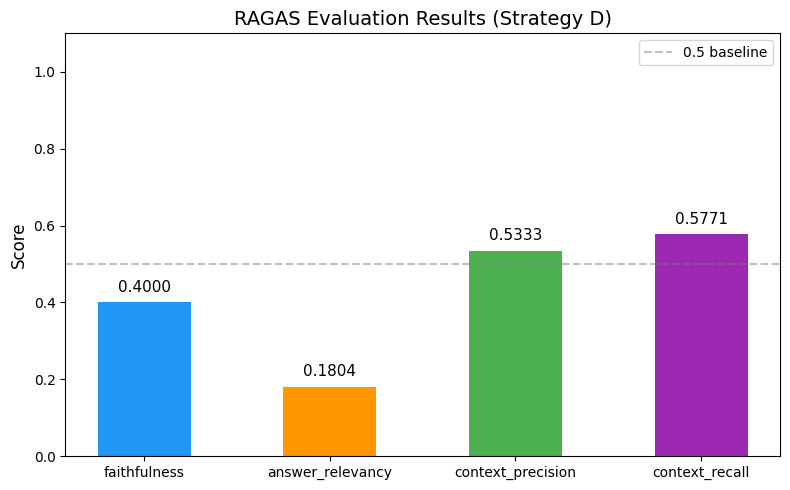

保存完了: /app/data/ragas_evaluation.png


In [68]:
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

metrics = list(ragas_results.keys())
scores = list(ragas_results.values())
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(metrics, scores, color=colors, width=0.5)

for bar, score in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{score:.4f}',
        ha='center', va='bottom', fontsize=11
    )

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('RAGAS Evaluation Results (Strategy D)', fontsize=14)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 baseline')
ax.legend()

plt.tight_layout()
plt.savefig('/app/data/ragas_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("保存完了: /app/data/ragas_evaluation.png")